In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Loading movie's ratings data
ratings = pd.read_csv("../Raw_Data/ratings.dat", header=None, delimiter="::")
#https://grouplens.org/datasets/movielens/1m/

### 1. Explory Data Analysis: Basics

In [3]:
ratings.shape

(1000209, 4)

In [4]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column  Non-Null Count    Dtype
---  ------  --------------    -----
 0   0       1000209 non-null  int64
 1   1       1000209 non-null  int64
 2   2       1000209 non-null  int64
 3   3       1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB


In [5]:
small_rat = ratings.iloc[0:10000, 0:4]

In [6]:
small_rat.shape

(10000, 4)

In [7]:
small_rat.head()

,0,1,2,3
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968
3,1,3408,4,978300275
4,1,2355,5,978824291


In [8]:
ratings.rename(columns={0:"UserID", 1:"MovieID", 2:"Rating", 3:"Timestamp"}, inplace=True)

In [9]:
small_rat = ratings.iloc[0:100000, 0:3]

#### 1.1 small sample properties : Ratings distribution

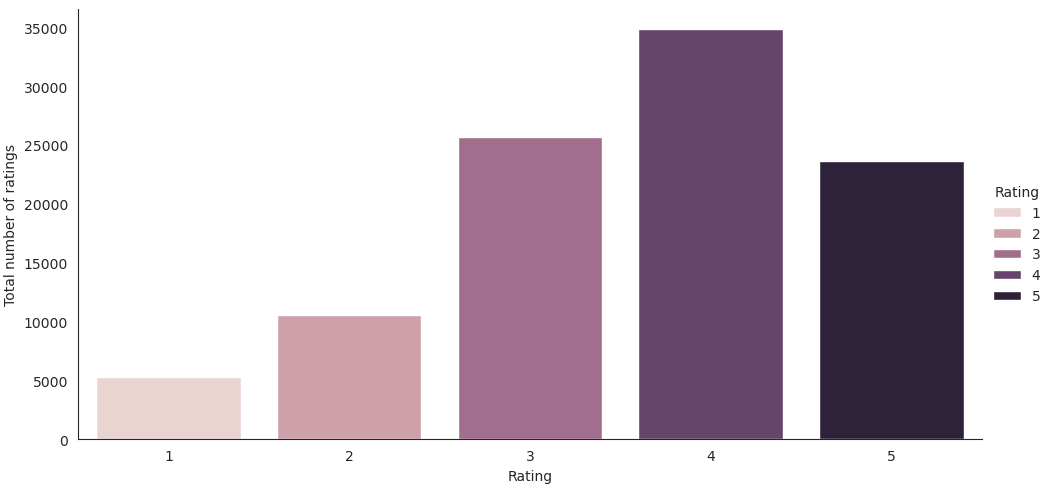

In [10]:
with sns.axes_style('white'):
    g = sns.catplot(data=small_rat, x="Rating", hue="Rating", aspect=2.0,kind='count')
    g.set_ylabels("Total number of ratings")

In [11]:
small_rat.Rating.describe()

count    100000.000000
mean          3.610140
std           1.113338
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: Rating, dtype: float64

#### 1.2 Number of movies and users

In [12]:
max_Movie_Id = small_rat.MovieID.max()
print("Max ID of movies in the small ratings sample: " + str(max_Movie_Id))

Max ID of movies in the small ratings sample: 3952


In [13]:
count_Movie_Id = small_rat.MovieID.nunique()
print("Number of Movie ID in the small ratings sample: " + str(count_Movie_Id))

Number of Movie ID in the small ratings sample: 3264


In [14]:
max_User_Id = small_rat.UserID.max()
print("Max ID of User in the small ratings sample: " + str(max_User_Id))

Max ID of User in the small ratings sample: 669


In [15]:
count_User_Id = small_rat.UserID.nunique()
print("Number of User ID in the small ratings sample: " + str(count_User_Id))

Number of User ID in the small ratings sample: 669


In [16]:
# we withdraw the last user to get a fair estimation of the taste of every users
small_rat = small_rat[small_rat["UserID"] != max_User_Id]
small_rat.shape

(99987, 3)

#### 1.4 Number of ratings per movie

In [17]:
nb_ratings_per_movie = small_rat[["MovieID", "UserID"]].groupby(by = "MovieID").count()

In [18]:
nb_ratings_per_movie.describe()

,UserID
count,3264.000000
mean,30.633272
std,42.128170
min,1.000000
25%,5.000000
50%,15.000000
75%,40.000000
max,406.000000


array([[<Axes: title={'center': 'UserID'}>]], dtype=object)

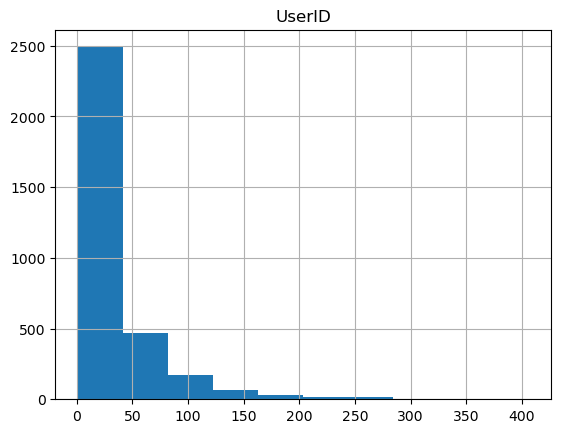

In [19]:
nb_ratings_per_movie.hist()

#### 1.5 Number of ratings per user

In [20]:
nb_ratings_per_user = small_rat[["MovieID", "UserID"]].groupby(by = "UserID").count()

In [21]:
nb_ratings_per_user.describe()

,MovieID
count,668.000000
mean,149.681138
std,172.474499
min,20.000000
25%,43.000000
50%,87.000000
75%,182.250000
max,1226.000000


array([[<Axes: title={'center': 'MovieID'}>]], dtype=object)

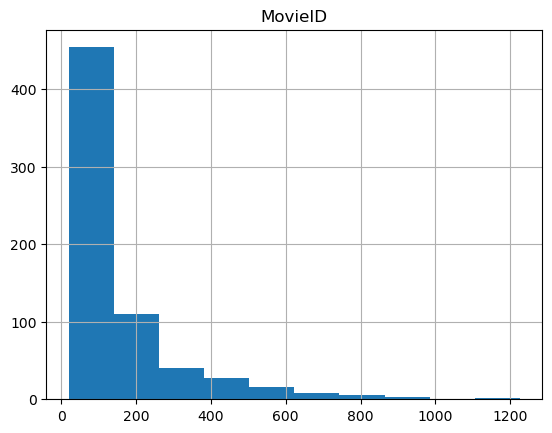

In [22]:
nb_ratings_per_user.hist()

In [23]:
# We select only users with 40 or more ratings
nb_ratings_per_user.head()

,MovieID
UserID,
1,53
2,129
3,51
4,21
5,198


In [24]:
df_user = nb_ratings_per_user.reset_index()
df_user.head()

,UserID,MovieID
0,1,53
1,2,129
2,3,51
3,4,21
4,5,198


In [25]:
df_user = df_user[df_user["MovieID"] >= 40]
selected_user = df_user.loc[:,"UserID"]
selected_user.head(10)

0      1
1      2
2      3
4      5
5      6
7      8
8      9
9     10
10    11
12    13
Name: UserID, dtype: int64

In [26]:
selected_user = selected_user.to_list()
selected_user[:10]

[1, 2, 3, 5, 6, 8, 9, 10, 11, 13]

In [27]:
small_rat = small_rat[small_rat["UserID"].isin(selected_user)]
small_rat["UserID"].nunique()

518

In [45]:
np.save("../transformed_Data/ratings_np.npy", ratings.to_numpy())

### 2. Preparation of the dataset for collaborative filtering

#### 2.1 Getting movie titles

In [28]:
# Loading movie's ratings data
movies = pd.read_csv("../Raw_Data/movies.dat", header=None, delimiter="::", on_bad_lines='skip', encoding='ISO-8859-1')

In [29]:
movies.head()

,0,1,2
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama
4,5,Father of the Bride Part II (1995),Comedy


In [30]:
movies_titles = movies.copy()

In [31]:
movies_titles.iloc[:,1] = movies_titles.iloc[:,1].apply(lambda x: x[0:-7])
movies_titles.head()

,0,1,2
0,1,Toy Story,Animation|Children's|Comedy
1,2,Jumanji,Adventure|Children's|Fantasy
2,3,Grumpier Old Men,Comedy|Romance
3,4,Waiting to Exhale,Comedy|Drama
4,5,Father of the Bride Part II,Comedy


In [32]:
movies_titles.rename(columns={0: "MovieID", 1: "title"}, inplace=True)
movies_titles.drop([2], axis=1, inplace=True)

In [33]:
movies_titles.head(10)

,MovieID,title
0,1,Toy Story
1,2,Jumanji
2,3,Grumpier Old Men
3,4,Waiting to Exhale
4,5,Father of the Bride Part II
5,6,Heat
6,7,Sabrina
7,8,Tom and Huck
8,9,Sudden Death
9,10,GoldenEye


In [34]:
movies_titles.tail(10)

,MovieID,title
3873,3943,Bamboozled
3874,3944,Bootmen
3875,3945,Digimon: The Movie
3876,3946,Get Carter
3877,3947,Get Carter
3878,3948,Meet the Parents
3879,3949,Requiem for a Dream
3880,3950,Tigerland
3881,3951,Two Family House
3882,3952,"Contender, The"


In [35]:
movies_titles.to_csv("../transformed_Data/MovieID_title.csv", index=False)

#### 2.2 User-item matrix creation

In [36]:
list_user = small_rat.UserID.unique()
list_user = sorted(list_user)
list_user[:10]

[np.int64(1),
 np.int64(2),
 np.int64(3),
 np.int64(5),
 np.int64(6),
 np.int64(8),
 np.int64(9),
 np.int64(10),
 np.int64(11),
 np.int64(13)]

In [37]:
small_rat.reset_index(drop=True, inplace=True)
small_rat.head()

,UserID,MovieID,Rating
0,1,1193,5
1,1,661,3
2,1,914,3
3,1,3408,4
4,1,2355,5


In [38]:
len(small_rat)

95812

In [39]:
# user-item or item-user matrix creation

def user_item_creation(ratings=small_rat, user_item = True):
    
    nb_users=ratings.UserID.nunique()
    nb_movies=ratings.MovieID.nunique()

    print(nb_users)
    print(nb_movies)

    # correspondance between userID and matrix index for axis 0
    user_corres = pd.DataFrame(columns=["index","UserID"])
    for i in range(ratings.UserID.nunique()):
        user_corres.loc[i, "index"] = i
        user_corres.loc[i, "UserID"] = sorted(ratings.UserID.unique())[i]

    user_corres.to_csv("../transformed_Data/user_corres_matrix_index.csv", index=False)

    # correspondance between userID and matrix index for axis 0
    movie_corres = pd.DataFrame(columns=["index","MovieID"])
    for i in range(ratings.MovieID.nunique()):
        movie_corres.loc[i, "index"] = i
        movie_corres.loc[i, "MovieID"] = sorted(ratings.MovieID.unique())[i]

    movie_corres.to_csv("../transformed_Data/movie_corres_matrix_index.csv", index=False)

    
    rat_mat = np.zeros([nb_users,nb_movies])

    # loop over ratings
    for i in range(len(ratings)):
        user_indice = user_corres[user_corres["UserID"] == ratings.loc[i, "UserID"]].reset_index().loc[0, "index"]
        movie_indice = movie_corres[movie_corres["MovieID"] == ratings.loc[i, "MovieID"]].reset_index().loc[0, "index"]
        rat_mat[user_indice,movie_indice] = ratings.iloc[i,2]

    print(np.size(rat_mat))
    print(np.max(rat_mat))
    print(np.sum(rat_mat))

    if user_item:    
        return rat_mat
    else: 
        return np.transpose(rat_mat)

In [40]:
#rat_mat = user_item_creation()

In [41]:
# the same but using numpy arrays to be faster
def np_user_item_creation(ratings=small_rat, user_item = True):
    
    nb_users=ratings.UserID.nunique()
    nb_movies=ratings.MovieID.nunique()

    print(nb_users)
    print(nb_movies)

    # correspondance between userID and matrix index for axis 0
    user_corres = np.zeros([nb_users,2])
    for i in range(nb_users):
        user_corres[i, 0] = i
        user_corres[i, 1] = sorted(ratings.UserID.unique())[i]

    np.save("../transformed_Data/user_corres_matrix_index.npy", user_corres)

    # correspondance between userID and matrix index for axis 0
    movie_corres = np.zeros([nb_movies,2])
    for i in range(nb_movies):
        movie_corres[i, 0] = i
        movie_corres[i, 1] = sorted(ratings.MovieID.unique())[i]

    np.save("../transformed_Data/movie_corres_matrix_index.npy", movie_corres)

    ratings_np = ratings.to_numpy()

    rat_mat = np.zeros([nb_users,nb_movies])

    # loop over ratings
    for i in range(len(ratings)):
        user_indice = np.where(user_corres[:,1] == ratings_np[i, 0])
        
        # user_corres[user_corres["UserID"] == ratings.loc[i, "UserID"]].reset_index().loc[0, "index"]
        movie_indice = np.where(movie_corres[:,1] == ratings_np[i, 1])
        #movie_corres[movie_corres["MovieID"] == ratings.loc[i, "MovieID"]].reset_index().loc[0, "index"]
        rat_mat[user_indice,movie_indice] = ratings_np[i,2]

    print(np.size(rat_mat))
    print(np.max(rat_mat))
    print(np.sum(rat_mat))
        
    if user_item:    
        return rat_mat
    else: 
        return np.transpose(rat_mat)

In [42]:
u_i = True
rat_mat = np_user_item_creation(user_item = u_i)

518
3255
1686090
5.0
345190.0


In [43]:
if u_i:
    np.save("../transformed_Data/user_item_matrix.npy", rat_mat)
else:
    np.save("../transformed_Data/item_user_matrix.npy", rat_mat)